PHASE 2: DOWNSCALING AND HYBRID SAMPLING

Analyze crime frequency per year

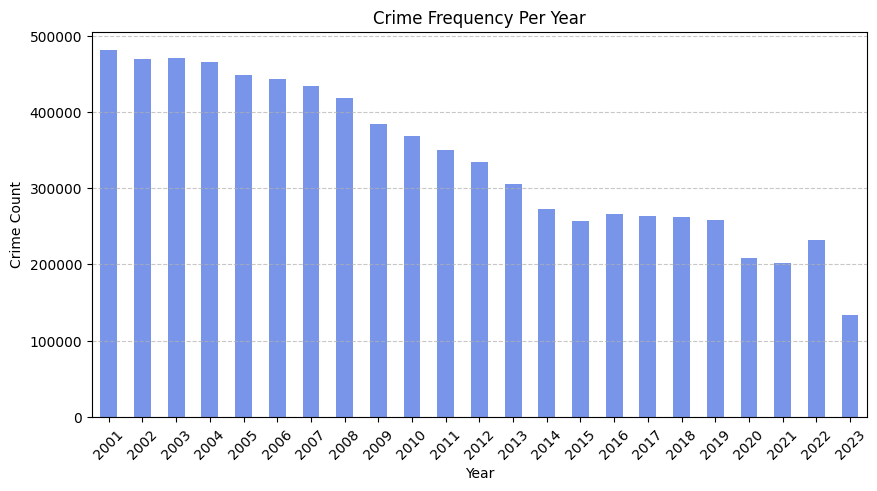

Date
2001    481008
2002    469939
2003    470707
2004    465940
2005    448704
2006    443729
2007    434034
2008    418493
2009    384703
2010    369013
2011    350199
2012    334443
2013    305154
2014    272568
2015    257062
2016    266361
2017    264095
2018    262616
2019    258276
2020    207948
2021    202163
2022    232222
2023    133222
dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset from Phase 1
file_path = "cleaned_crime_data.csv"  # Update if needed
df = pd.read_csv(file_path, parse_dates=["Date"])

# Group by year and count crimes
crime_per_year = df.groupby(df["Date"].dt.year).size()

# Plot the crime distribution over time
plt.figure(figsize=(10, 5))
crime_per_year.plot(kind="bar", color="royalblue", alpha=0.7)
plt.xlabel("Year")
plt.ylabel("Crime Count")
plt.title("Crime Frequency Per Year")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Display crime counts per year
print(crime_per_year)


Define Dynamic Sampling Strategy

In [3]:
import numpy as np

# Compute median crimes per year as a reference
median_crime_count = crime_per_year.median()

# Define dynamic minimum threshold (e.g., 1% of median, but at least 50 crimes)
min_crimes_per_year = max(50, int(0.01 * median_crime_count))

print(f"📌 Dynamic Minimum Crimes Per Year: {min_crimes_per_year}")


📌 Dynamic Minimum Crimes Per Year: 3344


Apply Hybrid Sampling

In [10]:
# Compute total dataset size
total_size = df.shape[0]

# Target final dataset size
target_size = 250000

# Compute new sampling ratio
sampling_ratio = target_size / total_size

print(f"📉 Adjusted Sampling Ratio: {sampling_ratio:.6f}")


📉 Adjusted Sampling Ratio: 0.032331


In [13]:
import pandas as pd

# Define a function to apply stratified sampling
def stratified_sample(group, min_size=5):
    """ Ensure at least `min_size` crimes per group while applying the sampling ratio. """
    sample_size = max(min_size, int(len(group) * sampling_ratio))
    return group.sample(n=min(len(group), sample_size), random_state=42)

# Apply stratified sampling across Year, Crime Type, and District
df_sampled = df.groupby(["Year", "Primary Type", "District"], group_keys=False).apply(
    lambda x: stratified_sample(x, min_size=5)
)

# Save the new downscaled dataset
df_sampled.to_csv("crime_data_sampled.csv", index=False)

# Display final shape
print(f"✅ Downscaled dataset shape: {df_sampled.shape}")
print(df_sampled["Year"].value_counts())  # Check yearly distribution
print(df_sampled["Primary Type"].value_counts())  # Check crime type balance
print(df_sampled["District"].value_counts())  # Check district balance

C:\Users\atuly\AppData\Local\Temp\ipykernel_21152\2805093486.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby(["Year", "Primary Type", "District"], group_keys=False).apply(


✅ Downscaled dataset shape: (272264, 15)
Year
2001    16338
2003    16039
2002    16025
2004    15919
2005    15355
2006    15209
2007    14893
2008    14411
2009    13341
2010    12855
2011    12284
2012    11766
2013    10807
2014     9817
2016     9708
2017     9691
2018     9687
2019     9478
2015     9385
2022     8527
2020     7792
2021     7565
2023     5372
Name: count, dtype: int64
Primary Type
THEFT                                52318
BATTERY                              45860
CRIMINAL DAMAGE                      28510
NARCOTICS                            23718
ASSAULT                              16242
OTHER OFFENSE                        15207
BURGLARY                             13494
MOTOR VEHICLE THEFT                  11980
DECEPTIVE PRACTICE                   10376
ROBBERY                               9266
CRIMINAL TRESPASS                     6688
WEAPONS VIOLATION                     3931
PROSTITUTION                          3045
PUBLIC PEACE VIOLATION            

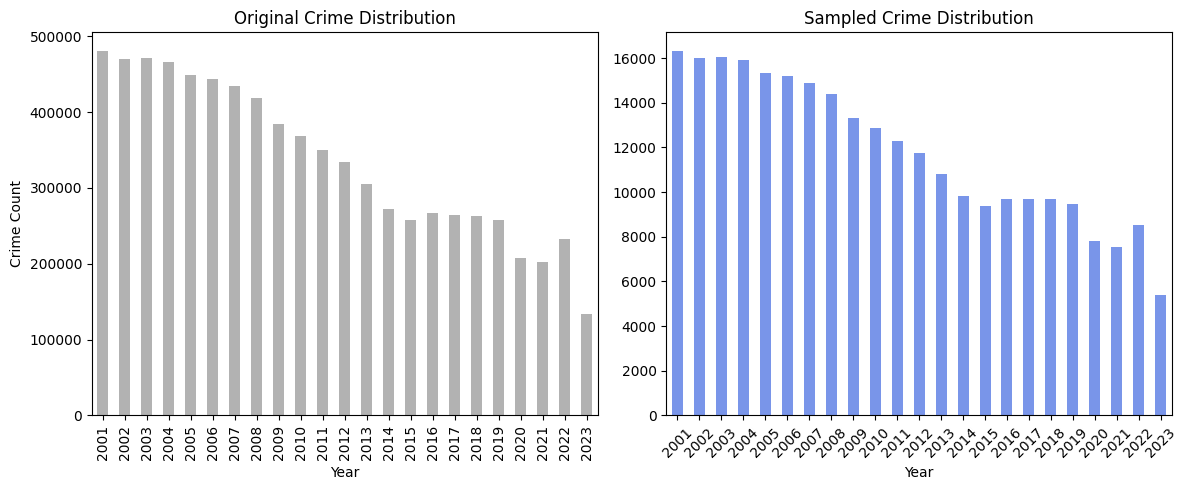

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Original dataset distribution
df["Year"].value_counts().sort_index().plot(kind="bar", color="gray", alpha=0.6, ax=ax[0])
ax[0].set_title("Original Crime Distribution")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Crime Count")

# Sampled dataset distribution
df_sampled["Year"].value_counts().sort_index().plot(kind="bar", color="royalblue", alpha=0.7, ax=ax[1])
ax[1].set_title("Sampled Crime Distribution")
ax[1].set_xlabel("Year")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
